# DLC Project for Stick Insect

This notebook is used to create, train the pose estimation model, and this is based on the DeepLabCut pipeline guide:

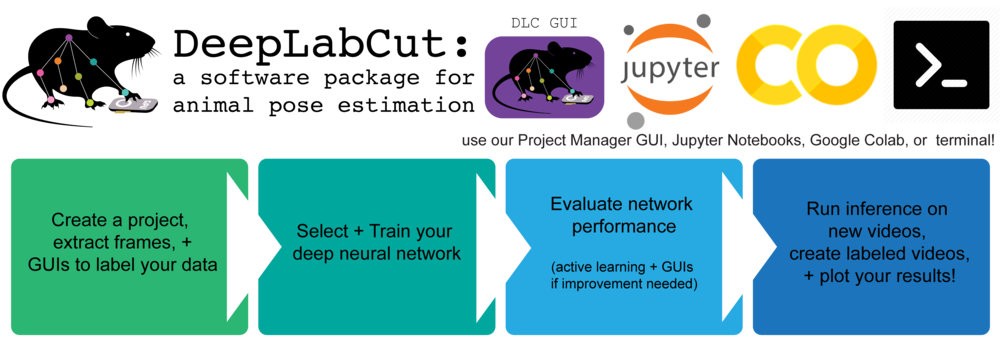
Figure 1. The DeepLabCut pipeline guide for pose estimation

(Taken from the DeepLabCut repo)

## 0) Import packages and check torch device

In [ ]:
import deeplabcut as dlc
dlc.__version__

In [ ]:
import torch
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
from pathlib import Path

`pwd` prints your current local path. Reason of this is just to double check that we are in the right directory.

In [ ]:
pwd

## 1) Create the project

By creating projects we keep our neural networks contained in specific projects, which is helpful if we want to use different neural network
architectures to analyze the data.

It is preferrable to use one project if we are tracking similar subjects/animals.


In [ ]:
PROJECT_NAME: str = "StickInsect_20251029"
EXPERIMENTER: str = "Rrezon Pllana"
VIDEO_DIR: str = "videos/" 
WORKING_DIR: str = "models/"
# Dynamically create a list of video paths in the VIDEO_DIR that match the pattern "PIC_*.mp4"
video_paths = [str(path) for path in Path(VIDEO_DIR).glob("PIC_*.mp4")]

path_config_file = dlc.create_new_project(PROJECT_NAME, EXPERIMENTER, video_paths, copy_videos=True)

It can be noticed that DeepLabCut has created a new folder based on our global variables: `PROJECT_NAME + _ + EXPERIMENTER + _ + today's date(YYYY-MM_DD)`.
Inside this folder there are folders created based on the workflow of DeepLabCut image in `imgs` folder

`create_new_project`: Creates the initial directory structure, subfolders, and default `config.yaml` file for a new project.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `project` | `str` | *Required* | Name of the project. |
| `experimenter` | `str` | *Required* | Name of the experimenter. |
| `videos` | `list[str]` | *Required* | List of full file paths to videos. If a directory path is provided, all videos of the specified `videotype` are imported. |
| `videotype` | `str` | `'.avi'` | Video extension filter used when specifying a directory in `videos` (e.g., `'.mp4'`). |
| `working_directory` | `str` | Current directory | Target directory where the project folder will be created. |
| `copy_videos` | `bool` | `False` | If `True`, copies videos into the project folder. If `False`, creates symbolic links (or moves videos if symlinking fails). |
| `multianimal` | `bool` | `False` | Set to `True` to create a multi-animal project. |
| `individuals` | `list[str] \| None` | `None` | List of individual identities for multi-animal tracking. Defaults to `['individual1', 'individual2', 'individual3']`. |

**Returns**
* **`str`**: Full path to the newly generated `config.yaml` file.

Note: 
- The `VIDEO_DIR` is a list input, so you can add multiple videos.
- The function returns the path, where your project is. You could also enter this manually (e.g. if the project is already created and you 
want to pick up where you stopped...) Enter the path of the config file that was just created from the above step (check the folder):
`path_config_file = "/home/name/deeplabcut_research/config.yaml"`

## 2) Modify the config.yaml file

Now that we got all the structure setup, we need to go to the `config.yaml` file and add the bodyparts names for our subject in this case 
stick insect.

In [ ]:
CONFIG_PATH: str = path_config_file
print(f"Configuration file created at: {CONFIG_PATH}")

In [ ]:
import yaml

with open(CONFIG_PATH, 'r') as file:
    config = yaml.safe_load(file)

# Update the config dictionary with the new values from the user input without editing the config.yaml file directly
config['numframes2pick'] = 22  # Update the number of frames to pick for labeling/refinement

# Check if the 'bodyparts' and 'skeleton' keys are presented correctly in the config dictionary
print("Number of frames to pick for labeling/refinement:", config['numframes2pick'])
print("Bodyparts:", config['bodyparts'])
print("Skeleton:", config['skeleton'])

## 3) Extract Frames and Label them

Now after having configured the `bodyparts` and `skeleton`, next step would be to select the frames that will be used for labeling.

A successful feature detector relies on selecting a diverse set of frames that capture the behavior of interest while including also edge cases, and that these are subsequently labeled.

To improve the robustness and generalizability of the feature detector, frames should be selected from multiple different sessions and if possible from different subjects/insects. Especially as in this case where we expect for stick insect to vary on color, body shape, and size.

Individual images should ideally not exceed 850 × 850 pixels. Although image resizing or cropping can be performed at a later stage, it is generally recommended to crop frames beforehand to remove unnecessary regions and retain only the relevant content.

The cropping results should always be inspected before proceeding. Once the cropped frames are deemed satisfactory, the labeling process can begin.

In [ ]:
%matplotlib inline
dlc.extract_frames(CONFIG_PATH, mode='automatic', userfeedback=False, crop=False)

`extract_frames`: Extracts representative video frames from project videos for manual labeling. Frames are selected from project videos using temporally uniform sampling (`"uniform"`), visual appearance clustering (`"kmeans"`), or manual interactive selection (`"manual"`). For multi-camera setups, `"match"` mode allows aligning extracted frames across different camera angles using epipolar geometry.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str` | *Required* | Full path to the `config.yaml` file. |
| `mode` | `str` | `'automatic'` | Extraction mode: `'automatic'`, `'manual'`, or `'match'` (matches frames across cameras). |
| `algo` | `str` | `'kmeans'` | Selection algorithm for automatic mode: `'kmeans'` (clustering) or `'uniform'` (evenly spaced). |
| `crop` | `bool \| str` | `False` | Frame cropping option: `True` (uses config settings), `False`, or `'GUI'` (draw interactively). |
| `userfeedback` | `bool` | `True` | If `True`, prompts for confirmation before processing each video. If `False`, processes all automatically. |
| `cluster_resizewidth` | `int` | `30` | Target image width (px) for downsampling during k-means clustering. |
| `cluster_step` | `int` | `1` | Sampling step size for k-means (e.g., `2` evaluates every 2nd frame to save RAM). |
| `cluster_color` | `bool` | `False` | If `True`, considers RGB channels during k-means. If `False`, converts images to grayscale. |
| `opencv` | `bool` | `True` | Uses OpenCV for video decoding and frame extraction. |
| `slider_width` | `int` | `25` | Width of the video frame slider in GUI mode (% of window). |
| `config3d` | `str \| None` | `None` | Path to the 3D project configuration file (required when `mode='match'`). |
| `extracted_cam` | `int` | `0` | Index of the reference camera whose frames are matched against other views. |
| `videos_list` | `list[str] \| None` | `None` | Specific list of video paths to process. If `None`, extracts all videos listed in `config.yaml`. |

**Returns**

* **`None`**


Note:
- Using `mode="match"` will overwrite previously extracted images for secondary camera views. Delete existing `CollectedData` CSV/H5 files before re-extracting matched frames.

- Automatic extraction reads `numframes2pick`, `start`, and `stop` parameters directly from `config.yaml`.
- To add new videos to an existing project, call `deeplabcut.add_new_videos()` before running `extract_frames`.

#### 3.1) Labeling Extracted Frames
Only videos specified in the configuration file can be used for frame extraction. The extracted frames for each video are stored in the project directory under the labeled-data subdirectory, where each video's frames are organized into a subdirectory named after the corresponding video.

The toolbox provides a dedicated labeling interface that can be used to annotate the extracted frames.

In [ ]:
%gui qt6
import napari

# If this is used, then first after opening the view, it is needed to go to Plugins -> napari-deeplabcut, to be able to proces multiple labels
# and also save the files correctly, otherwise it will not work properly.

# Next you drag and drop config file and the folder that contains the extracted frames you want to label.
napari.Viewer()

In [ ]:
# Alternative to napari.Viewer() command, it can be used to open the view with the config file and the folder that contains the extracted 
# frames you want to label.
dlc.label_frames(CONFIG_PATH)

`label_frames`: Launches the `napari-deeplabcut` interactive labeling GUI.
Opens the Napari-based graphical interface for annotating body parts on extracted video frames.
* **No arguments:** Launches an empty GUI where you can drag and drop an image folder directly.
* **`config_path` + `image_folder`:** Opens the specified image folder within the target project.
* **`config_path` only:** Automatically opens the first extracted image folder found in the project directory.

For detailed GUI usage instructions, see the [napari-deeplabcut Documentation](https://github.com/DeepLabCut/napari-deeplabcut?tab=readme-ov-file#usage).

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config_path` | `str \| Path \| None` | `None` | Full path to the project's `config.yaml` file. |
| `image_folder` | `str \| None` | `None` | Name or path of the specific image folder to open for labeling. |

**Returns**

* **`None`** *(Opens interactive Napari GUI)*


## 3.2) Check labels of extracted frames

This command is optional, however, it doesn't mean that is not important since checking that created labels are created and stored properly
is helpful in the long run, based on the importance that correct labeling creates good training datasets.

And if anything needs to change, then previous step should be run again!

In [ ]:
dlc.check_labels(CONFIG_PATH, draw_skeleton=True)

`check_labels`: Generates annotated image files to visually verify human ground-truth labels and skeleton connections.
Plots human-labeled body parts (and optional skeleton connections) directly onto extracted frames and saves them in subdirectories under 
`labeled-data/`. Use this step to verify label position accuracy and format integrity before creating training datasets.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str` | *Required* | Full path to the project's `config.yaml` file. |
| `Labels` | `list` | `['+']` | List of at least 3 matplotlib markers. The first marker represents the human ground truth location. |
| `scale` | `float` | `1.0` | Relative scaling factor for output image dimensions. |
| `dpi` | `int` | `100` | Output image resolution in dots per inch (DPI). |
| `draw_skeleton` | `bool` | `True` | If `True`, overlays skeleton lines connecting defined body parts. |
| `visualizeindividuals` | `bool` | `True` | Multi-animal projects only: `True` colors markers by individual, `False` colors markers by body part type. |

**Returns**

* **`None`** *(Generates image files in `labeled-data/<video_name>_labeled/`)*

## 4) Training dataset creation
After labeling the data, it is time to create the dataset and configurations about the training, this can be done running `create_training_dataset()`
function.

While creating the dataset, the user can create multiple shuffles if they want to benchmark the performance. After running this script the 
training dataset is created and saved in the project directory under the subdirectory `training-datasets`.

Furthermore `create_training_dataset()`, creates new subdirectories under `dlc-models-pytorch` and creates a `pytorch_config.yaml` file, 
defining the model architecture and containing various parameters used for training the network. For more check the 
[documentation for `pytorch_config.yaml`](https://deeplabcut.github.io/DeepLabCut/docs/pytorch/pytorch_config.html).

In [ ]:
# Run this command only if you  already labeled the frames (or you are training a previous model)
CONFIG_PATH: str = 'StickInsect_20251029-Rrezon Pllana-2026-08-06/config.yaml'

dlc.create_training_dataset(CONFIG_PATH)

`create_training_dataset`: Merges human-labeled data across all project frames into training/testing splits and builds network pose configuration files.

Consolidates all individual frame annotations (`CollectedData_*.h5/csv`) into a master training dataset file. It creates cross-validation splits (shuffles) with default or custom train/test ratios and generates engine-specific configuration files (`pose_cfg.yaml`) tailored to your chosen neural network architecture and augmentation pipeline.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str` | *Required* | Full path to the project's `config.yaml` file. |
| `num_shuffles` | `int` | `1` | Number of random train/test split shuffles to generate (e.g., `3` creates shuffles 1, 2, and 3). |
| `Shuffles` | `list[int] \| None` | `None` | Specific list of shuffle IDs to generate instead of `num_shuffles`. |
| `windows2linux` | `bool` | `False` | Fixes path formatting if training on Linux using a dataset created on Windows. |
| `userfeedback` | `bool` | `True` | If `True`, prompts for confirmation before overwriting existing split files. |
| `trainIndices` | `list[list[int]] \| None` | `None` | Custom frame index lists for the training split. |
| `testIndices` | `list[list[int]] \| None` | `None` | Custom frame index lists for the test split. |
| `net_type` | `str \| None` | `None` | Neural network backbone architecture (e.g., PyTorch: `'rtmpose_m'`, `'hrnet_w32'`, `'cspnext_m'`; TF: `'resnet_50'`, `'efficientnet-b0'`). |
| `detector_type` | `str \| None` | `None` | Object detector architecture for PyTorch top-down models (e.g., `'ssdlite'`, `'fasterrcnn_mobilenet_v3_large_fpn'`). |
| `augmenter_type` | `str \| None` | `None` | Image augmentation pipeline (PyTorch: `'albumentations'`; TF: `'imgaug'`, `'scalecrop'`, `'default'`). |
| `posecfg_template` | `str \| None` | `None` | Path to a custom `pose_cfg.yaml` template file (TensorFlow engine only). |
| `superanimal_name` | `str` | `""` | Name of SuperAnimal model for transfer learning template initialization (TensorFlow engine only). |
| `weight_init` | `WeightInitialization \| None` | `None` | Weight initialization configuration object (PyTorch engine only). |
| `engine` | `Engine \| None` | `None` | Target framework (`'TF'` or `'PYTORCH'`). Defaults to setting in `config.yaml`. |
| `ctd_conditions` | `int \| str \| Path \| tuple \| None` | `None` | Conditions for Conditional Top-Down (CTD) models (shuffle ID, prediction path, or snapshot tuple). |

**Returns**

* **`list[tuple] \| None`**: Returns a list of tuples containing `(trainFraction, shuffle, trainIndices, testIndices)` upon success, or `None` if dataset creation fails.

**Note**

* **PyTorch Engine Backbones:** Call `deeplabcut.pose_estimation_pytorch.available_models()` and `available_detectors()` to query available networks and object detectors.
* **Conditional Top-Down (CTD):** `ctd_conditions` allows pairing top-down pose models with existing bottom-up network outputs or saved prediction files.

In [ ]:
# Running with GPU and specifying the network type as "resnet_50" and engine as "pytorch"
dlc.create_training_dataset(CONFIG_PATH, net_type="resnet_50", engine=dlc.Engine.PYTORCH)

## 5) Training the network

After creating the dataset for training and testing, it is time to actually train the model/network to estimate the pose, for this step it is
possible to also edit the `.../project-name/dlc-models-pytorch/.../pytorch_config.yaml` for changing specifit network parameters, or even data augmentation parameters.  

For more check the [documentation for `pytorch_config.yaml`](https://deeplabcut.github.io/DeepLabCut/docs/pytorch/pytorch_config.html).

In [ ]:
dlc.train_network(
    CONFIG_PATH,   # path to the config.yaml file
    shuffle=1,     # shuffle the training data
    save_epochs=5, # save the model every 5 epochs
    epochs=200,    # number of training epochs
    batch_size=8,  # batch size for training (changing this number changes how we utilize the GPU memory)
    device=device,  # specify the device to use (GPU or CPU)
)

# This will run until you stop it (CTRL+C), or hit "STOP" icon, or when it hits the end.

`train_network`: Trains the neural network using labeled dataset shuffles and generates model checkpoint snapshots.
Executes network training on a specified training dataset split (shuffle). Supports both PyTorch and TensorFlow engines, allowing customization of training duration (epochs/iterations), batch sizes, snapshot saving intervals, GPU device selection, and model checkpoint resumption.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str \| Path` | *Required* | Full path to the project's `config.yaml` file. |
| `shuffle` | `int` | `1` | Shuffle ID of the training dataset split to use. |
| `trainingsetindex` | `int` | `0` | Index of the training fraction listed in `config.yaml`. |
| `epochs` | `int \| None` | `None` | Maximum training epochs (**PyTorch engine**). Overrides `pytorch_config.yaml`. |
| `maxiters` | `int \| None` | `None` | Maximum training iterations (**TensorFlow engine**). Overrides `pose_config.yaml`. |
| `save_epochs` | `int \| None` | `None` | Epoch interval for saving snapshots (**PyTorch engine**). |
| `saveiters` | `int \| None` | `None` | Iteration interval for saving snapshots (**TensorFlow engine**). |
| `device` | `str \| None` | `None` | Target execution device for PyTorch (e.g., `'cuda:0'`, `'cpu'`). |
| `gputouse` | `str \| None` | `None` | Target GPU index for TensorFlow (e.g., `'0'`). |
| `batch_size` | `int \| None` | `None` | Training batch size (**PyTorch engine**). |
| `max_snapshots_to_keep` | `int \| None` | `None` | Maximum number of recent snapshot files to retain on disk. |
| `snapshot_path` | `str \| Path \| None` | `None` | Path to a pre-trained pose model snapshot to resume training from (**PyTorch engine**). |
| `detector_path` | `str \| Path \| None` | `None` | Path to a pre-trained detector snapshot for top-down models (**PyTorch engine**). |
| `detector_epochs` | `int \| None` | `None` | Number of epochs to train the top-down object detector (**PyTorch engine**). |
| `detector_batch_size` | `int \| None` | `None` | Batch size for training the object detector (**PyTorch engine**). |
| `detector_save_epochs` | `int \| None` | `None` | Snapshot saving frequency for the detector (**PyTorch engine**). |
| `pose_threshold` | `float` | `0.1` | Minimum confidence threshold for memory-replay pseudo-predictions (**PyTorch engine**). |
| `keepdeconvweights` | `bool` | `True` | Restores deconvolution layer weights from snapshot. Set `False` if bodyparts count changed. |
| `allow_growth` | `bool` | `True` | Enables dynamic GPU VRAM allocation to prevent OOM errors (**TensorFlow engine**). |
| `engine` | `Engine \| None` | `None` | Training framework (`'TF'` or `'PYTORCH'`). Defaults to value in dataset metadata. |
| `pytorch_cfg_updates` | `dict \| None` | `None` | Dictionary of dot-separated path updates to override PyTorch configuration values. |

**Returns**

* **`None`** *(Saves model snapshots inside `dlc-models/`)*


## 6) Network Evaluation

After training is advisable to check how well did the network perform the training, and this can be done by using the function `evaluate_network()`,
which creates a subdirectory `evaluation-results-pytorch` and stores the evaluation results as a `.csv` file

In [ ]:
dlc.evaluate_network(CONFIG_PATH, plotting=True, Shuffles=[1])

`evaluate_network`: Evaluates trained neural network snapshots against ground-truth labels and calculates pixel prediction errors (RMSE).
Computes evaluation metrics (root-mean-square error in pixels) for training and test datasets across saved model snapshots. Results are saved as `.h5` and `.csv` files inside the project's `evaluation-results/` directory. To evaluate all stored snapshots at once, set `snapshotindex: all` in `config.yaml` or pass `snapshotindex="all"` via `torch_kwargs`.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str \| Path` | *Required* | Full path to the project's `config.yaml` file. |
| `Shuffles` | `Iterable[int]` | `(1,)` | List or tuple of dataset shuffle indices to evaluate. |
| `trainingsetindex` | `int \| str` | `0` | Training set fraction index or `'all'` to evaluate all fractions. |
| `plotting` | `bool \| str` | `False` | Plots predicted keypoints on evaluation images: `True` (or `'bodypart'`), `'individual'`, or `False`. |
| `show_errors` | `bool` | `True` | Displays train and test pixel errors (RMSE) in console output. |
| `comparisonbodyparts` | `str \| list[str]` | `'all'` | Subset of body parts used to compute the average evaluation error. |
| `per_keypoint_evaluation` | `bool` | `False` | Saves a detailed `{model_name}-keypoint-results.csv` containing RMSE for each individual keypoint. |
| `snapshots_to_evaluate` | `list[str] \| None` | `None` | Specific list of snapshot names to evaluate (e.g., `["snapshot-5000", "snapshot-7500"]`). |
| `pcutoff` | `float \| list \| dict \| None` | `None` | Likelihood confidence threshold for metric calculation (**PyTorch engine**). |
| `gputouse` | `str \| None` | `None` | Target GPU index for evaluation (e.g., `'0'`). |
| `rescale` | `bool` | `False` | Resizes images to `global_scale` during inference while reporting errors in original pixel scale. |
| `modelprefix` | `str` | `""` | Optional directory prefix containing DeepLabCut models. |
| `engine` | `Engine \| None` | `None` | Framework engine override (`'TF'` or `'PYTORCH'`). Defaults to dataset metadata. |
| `**torch_kwargs` | `dict` | N/A | PyTorch-specific overrides (e.g., `snapshotindex="all"`, `detector_snapshot_index=0`). |

**Returns**

* **`None`** *(Saves evaluation tables and diagnostic plots in `evaluation-results/`)*

## 7) Video Analysis

Here the function below analyzes new videos, and the user can choose the best model from evaluation results and specify the correct snapshot index
for the variable `snapshotindex` in `config.yaml` file.

If this is not done, then by default the most recent snapshot is taken to analyze the video.

In [ ]:
CONFIG_PATH: str = 'StickInsect_20251029-Rrezon Pllana-2026-08-06/config.yaml' # overrides the previous config path, if a
                                                                               # specific (project) config path is analyzed.
VIDEO_DIR:str = 'videos/'
# Dynamically create a list of video paths in the VIDEO_DIR that match the pattern "PIC_*.mp4"
video_paths = [str(path) for path in Path(VIDEO_DIR).glob("PIC_*.mp4")]

In [ ]:
dlc.analyze_videos(CONFIG_PATH, videos=video_paths, videotype='mp4', 
                   shuffle=1, trainingsetindex=0, gputouse=None, save_as_csv=False,
                   destfolder=VIDEO_DIR, batchsize=1, cropping=None,
                   dynamic=(False, 0.5, 10))

`analyze_videos`: Runs inference on target videos using a trained DeepLabCut model and extracts body part coordinates and confidence scores.
Evaluates frame-by-frame pose predictions across specified videos. The predicted body part locations $(x, y)$ and confidence likelihoods are saved as Hierarchical Data Format (`.h5`) files and optional `.csv` files. For multi-animal projects, automatic identity tracking and assembly can be performed in the same pipeline step.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str` | *Required* | Full path to the project's `config.yaml` file. |
| `videos` | `list[str]` | *Required* | List of full video paths or a directory path containing videos to analyze. |
| `videotype` | `str` | `""` | File extension filter when `videos` is a directory (e.g., `'.mp4'`). |
| `shuffle` | `int` | `1` | Shuffle ID of the trained network split to use for inference. |
| `trainingsetindex` | `int` | `0` | Index of the training set fraction listed in `config.yaml`. |
| `save_as_csv` | `bool` | `False` | If `True`, exports prediction arrays as `.csv` files alongside `.h5`. |
| `destfolder` | `str \| None` | `None` | Target folder for output files. Defaults to the directory containing each video. |
| `dynamic` | `tuple` | `(False, 0.5, 10)` | Dynamic cropping tuple `(enabled, threshold, margin)` to restrict bounding box search around tracked targets. |
| `auto_track` | `bool` | `True` | Multi-animal: Automatically converts raw detections into individual animal tracks. |
| `n_tracks` | `int \| None` | `None` | Multi-animal: Number of distinct individuals to reconstruct (overrides config defaults). |
| `animal_names` | `list[str] \| None` | `None` | Multi-animal: Custom list of individual identity labels. |
| `calibrate` | `bool` | `False` | Multi-animal: Uses training data to calibrate assembly rules against missing keypoints. |
| `identity_only` | `bool` | `False` | Multi-animal: Relies strictly on neural identity predictions for track assembly. |
| `use_shelve` | `bool` | `False` | Writes predictions to disk iteratively on the fly to prevent high RAM consumption. |
| `robust_nframes` | `bool` | `False` | Reads video frame-by-frame to accurately count total frames, bypassing corrupt metadata. |
| `batchsize` | `int \| None` | `None` | Batch size for inference (**TensorFlow engine**). |
| `cropping` | `list[int] \| None` | `None` | Bounding box coordinates `[x1, x2, y1, y2]` applied to all videos (**TensorFlow engine**). |
| `gputouse` | `str \| None` | `None` | Target GPU index (**TensorFlow engine**). |
| `engine` | `Engine \| None` | `None` | Inference engine (`'TF'` or `'PYTORCH'`). Defaults to value in network metadata. |
| `**torch_kwargs` | `dict` | N/A | Extra parameters passed to PyTorch API (e.g., `device='cuda:0'`). |

**Returns**

* **`str`**: The `DLCScorer` string name used as the suffix for generated prediction files.

## Optional 1) Outlier Frames Extraction and Refinement

In this optional step it searches through analyzed videos to find frames where model performed poorly ( likelihood drops significantly) 
and extracts these frames using the function `extract_outlier_frames()`.

To refine/fix these outlier frames it is done using `refine_labels()` function, which allows to move the predicted labels and correct their location
by the user.

In [ ]:
# Used to create the video paths
VIDEO_DIR:str = 'videos/'
# Dynamically create a list of video paths in the VIDEO_DIR that match the pattern "PIC_*.mp4"
video_paths = [str(path) for path in Path(VIDEO_DIR).glob("PIC_*.mp4")]

In [ ]:
dlc.extract_outlier_frames(CONFIG_PATH, video_paths)  # pass a specific video

`extract_outlier_frames`: Identifies and extracts problematic or low-confidence frames from analyzed videos to perform active learning network refinement.
Filters video frames where network predictions exhibit high uncertainty, sudden spatial jumps, or fitting deviations. Extracted outlier images are saved into individual folders inside `labeled-data/`, ready for human re-labeling (`refine_labels`) and subsequent model retraining to iteratively boost network accuracy.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str` | *Required* | Full path to the project's `config.yaml` file. |
| `videos` | `list[str]` | *Required* | List of video paths or a directory path containing videos to evaluate. |
| `videotype` | `str` | `""` | Extension filter when `videos` is a directory (e.g., `'.mp4'`). |
| `shuffle` | `int` | `1` | Shuffle ID of the dataset split used during video analysis. |
| `trainingsetindex` | `int` | `0` | Index of the training set fraction listed in `config.yaml`. |
| `outlieralgorithm` | `str` | `'jump'` | Detection algorithm: `'jump'`, `'fitting'`, `'uncertain'`, `'manual'`, or `'list'`. |
| `epsilon` | `float` | `20` | Distance threshold in pixels for `'jump'` detection or fitting bound for `'fitting'`. |
| `p_bound` | `float` | `0.01` | Confidence likelihood cutoff threshold for `'uncertain'` frame selection. |
| `comparisonbodyparts` | `str \| list[str]` | `'all'` | Body part or list of body parts to evaluate for outliers. |
| `extractionalgorithm` | `str` | `'kmeans'` | Frame selection strategy applied across detected candidates (`'kmeans'` or `'uniform'`). |
| `frames2use` | `list[int] \| None` | `None` | Specific frame index list provided when `outlieralgorithm='list'`. |
| `ARdegree` | `int` | `3` | Autoregressive degree for SARIMAX time-series model (`'fitting'`). |
| `MAdegree` | `int` | `1` | Moving Average degree for SARIMAX time-series model (`'fitting'`). |
| `alpha` | `float` | `0.01` | Significance level for ARIMA confidence interval detection (`'fitting'`). |
| `automatic` | `bool` | `False` | Performs extraction automatically without interactive user prompts. |
| `cluster_resizewidth` | `int` | `30` | Image downsampling width used during k-means clustering. |
| `cluster_color` | `bool` | `False` | Includes color channels during k-means image vectorization if `True`. |
| `savelabeled` | `bool` | `False` | Draws predicted keypoints onto extracted frame images for visual inspection. |
| `copy_videos` | `bool` | `False` | Copies newly processed videos into the project folder instead of creating symlinks. |
| `destfolder` | `str \| None` | `None` | Folder where analysis results (`.h5`) are located. Defaults to the video directory. |
| `track_method` | `str` | `""` | Multi-animal tracking method (`'box'`, `'skeleton'`, or `'ellipse'`). |
| `opencv` | `bool` | `True` | Uses OpenCV for video frame extraction instead of MoviePy. |

**Returns**

* **`None`** *(Saves extracted image frames to `labeled-data/<video_name>/`)*

**Key Outlier Algorithms**

* **`'jump'`**: Identifies frames where a body part moves more than `epsilon` pixels in a single frame.
* **`'uncertain'`**: Identifies frames where any body part prediction falls below the `p_bound` likelihood threshold.
* **`'fitting'`**: Fits a time-series model (SARIMAX) to keypoint trajectories and flags positions deviating beyond `epsilon`.

In [ ]:
%gui qt6
dlc.refine_labels(CONFIG_PATH)

`refine_labels`: Launches the interactive `napari-deeplabcut` graphical user interface to inspect, adjust, and correct predicted keypoint labels during active learning.

Opens the `napari-deeplabcut` annotation workspace for reviewing and correcting model predictions on extracted outlier frames or manually added images. In current DeepLabCut versions, `refine_labels` is a direct alias for `label_frames` (`refine_labels = label_frames`). Correcting and saving labels updates the project's ground-truth annotations inside `labeled-data/`, preparing the dataset for model retraining.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config_path` | `str \| Path \| None` | `None` | Full path to the project's `config.yaml` file. |
| `image_folder` | `str \| None` | `None` | Subfolder name inside `labeled-data/` to open (e.g., `'2026-01-15-video1'`). |

**Returns**

* **`None`** *(Launches interactive Napari GUI)*

**Active Learning Workflow & GUI Interaction**

1. **Functional Equivalence:** `refine_labels` and `label_frames` invoke the same underlying `launch_napari()` function. While `label_frames` is typically used during initial project setup and `refine_labels` during active learning iterations, both open identical annotation tools.
2. **Directory Resolution:** 
   * If both `config_path` and `image_folder` are provided, the GUI loads `labeled-data/<image_folder>/`.
   * If only `config_path` is passed, it automatically defaults to opening the first directory inside `labeled-data/`.
   * If no parameters are passed (`deeplabcut.refine_labels()`), an empty GUI launches where image directories can be manually drag-and-dropped.

## 9) Creation of Labeled Video

This section will visualize all the predicted poses and create a mp4 video format. The location where this video is saved is same as the
original videos directory.

In [ ]:
dlc.create_labeled_video(CONFIG_PATH, video_paths,  videotype='.mp4', destfolder=VIDEO_DIR)

`create_labeled_video`: Generates annotated MP4 videos overlaying predicted body part keypoints, skeletons, trajectory trails, and bounding boxes onto analyzed video frames.
Creates visualization videos from existing `.h5` or `.csv` pose predictions generated by `deeplabcut.analyze_videos`. Supports fast OpenCV rendering or Matplotlib frame customization, along with options for skeleton drawing, confidence-based transparency (alpha mapping), motion trajectory trails, and point-light biological motion displays ("Johansson movies").

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str` | *Required* | Full path to the project's `config.yaml` file. |
| `videos` | `list[str]` | *Required* | List of video file paths or a directory path containing videos to label. |
| `videotype` | `str` | `""` | Extension filter when `videos` is a directory (e.g., `'.mp4'`). |
| `shuffle` | `int` | `1` | Dataset shuffle index used during video analysis. |
| `trainingsetindex` | `int` | `0` | Index of the training set fraction listed in `config.yaml`. |
| `filtered` | `bool` | `False` | Uses smoothed predictions (from `deeplabcut.filterpredictions`) instead of raw outputs. |
| `fastmode` | `bool` | `True` | Uses OpenCV for high-speed video rendering (`True`) vs. Matplotlib for fine visual control (`False`). |
| `save_frames` | `bool` | `False` | Saves individual annotated frame images before combining them into a video. |
| `keypoints_only` | `bool` | `False` | Hides video background, rendering only keypoints on a black canvas ("Johansson movie"). |
| `Frames2plot` | `list[int] \| None` | `None` | Specific frame indices to save (requires `save_frames=True`). |
| `displayedbodyparts` | `str \| list[str]` | `'all'` | Subset of body parts to render in the video. |
| `displayedindividuals` | `str \| list[str]` | `'all'` | Subset of individual animals to display (multi-animal projects). |
| `draw_skeleton` | `bool` | `False` | Connects keypoints with line segments according to project skeleton rules. |
| `skeleton` | `list` | `[]` | Custom skeleton pair connections overriding project configuration. |
| `skeleton_color` | `str` | `'white'` | Color name or hex code for skeleton line connections. |
| `trailpoints` | `int` | `0` | Number of historical frames to draw motion trajectory trails behind keypoints. |
| `dotsize` | `int` | `8` | Marker point radius/size for plotted keypoints. |
| `colormap` | `str` | `'rainbow'` | Matplotlib colormap used for keypoint markers. |
| `color_by` | `str` | `'bodypart'` | Color scheme grouping: `'bodypart'` or `'individual'`. |
| `pcutoff` | `float \| None` | `None` | Minimum likelihood confidence required to plot keypoints. |
| `confidence_to_alpha` | `bool \| Callable` | `False` | Dynamically scales marker opacity based on prediction likelihood score. |
| `plot_bboxes` | `bool` | `True` | Draws bounding boxes for top-down models (**PyTorch engine**). |
| `bboxes_pcutoff` | `float \| None` | `None` | Confidence threshold for rendering bounding boxes (**PyTorch engine**). |
| `codec` | `str` | `'mp4v'` | FourCC video compression codec (e.g., `'mp4v'`, `'XVID'`). |
| `outputframerate` | `int \| None` | `None` | Output video FPS override (requires `save_frames=True`). |
| `destfolder` | `Path \| str \| None` | `None` | Target output directory. Defaults to the source video directory. |
| `overwrite` | `bool` | `False` | Overwrites existing labeled videos if set to `True`. |
| `track_method` | `str` | `""` | Multi-animal tracking method (`'box'`, `'skeleton'`, or `'ellipse'`). |

**Returns**

* **`list[bool]`**: List of boolean status values (`True` for each successfully rendered video).

**Visualization Features**

* **Point-Light Displays (`keypoints_only=True`):** Removes the background video completely, leaving only predicted markers against a black background to analyze motion kinematics.
* **Trajectory History (`trailpoints > 0`):** Draws continuous motion trails for past $N$ frames to visualize trajectory paths.
* **Alpha Scaling (`confidence_to_alpha`):** When enabled or supplied with a mapping function $f(\text{score}) \to [0, 1]$, low-confidence predictions fade out transparently rather than popping out abruptly.


## 10) Plotting the trajectories of analyzed videos

After creating the videos with pose predictions and labeling them, it is time to plot the trajectories of each label, and some other metrics of them.

The plots can be found in the folder `plot-poses` at the original videos location.

In [ ]:
%matplotlib notebook
dlc.plot_trajectories(CONFIG_PATH, video_paths)

`plot_trajectories`: Generates 2D trajectory maps, $x/y$ coordinate time-series plots, and prediction likelihood trace graphs for analyzed video pose estimations.
Creates diagnostic visualization plots for predicted keypoint trajectories across video frames. Generates both spatial maps ($x$ vs. $y$ coordinates) and temporal trace plots ($x$ and $y$ coordinates vs. time, alongside likelihood scores vs. time). Figures are saved in a `plot-poses` subdirectory within each video folder or specified `destfolder`. Useful for quality control, kinematic analysis, and detecting tracking jumps or low-confidence segments.

**Parameters**

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| `config` | `str \| Path` | *Required* | Full path to the project's `config.yaml` file. |
| `videos` | `list[str]` | *Required* | List of video file paths or a directory path containing videos to evaluate. |
| `videotype` | `str` | `""` | Extension filter when `videos` is a directory (e.g., `'.mp4'`). |
| `shuffle` | `int` | `1` | Dataset shuffle index used during video analysis. |
| `trainingsetindex` | `int` | `0` | Index of the training set fraction listed in `config.yaml`. |
| `filtered` | `bool` | `False` | Uses smoothed predictions (from `deeplabcut.filterpredictions`) instead of raw outputs. |
| `displayedbodyparts` | `str \| list[str]` | `'all'` | Subset of body parts to include in trajectory plots. |
| `displayedindividuals` | `str \| list[str]` | `'all'` | Subset of individual animals to plot (multi-animal projects). |
| `showfigures` | `bool` | `False` | Interactively displays figures during execution. |
| `imagetype` | `str` | `'.png'` | File extension format for saved figures (`'.png'`, `'.svg'`, `'.jpg'`, `'.tif'`). |
| `resolution` | `int` | `100` | Resolution (DPI) of saved figure images. |
| `linewidth` | `float` | `1.0` | Line width for trajectory lines and likelihood traces. |
| `pcutoff` | `float \| None` | `None` | Minimum confidence threshold override for plotting coordinate points. |
| `destfolder` | `str \| Path \| None` | `None` | Output directory. Defaults to the directory containing each video. |
| `track_method` | `str` | `""` | Multi-animal tracking method (`'box'`, `'skeleton'`, or `'ellipse'`). |
| `modelprefix` | `str` | `""` | Optional directory prefix containing DeepLabCut models. |

**Returns**

* **`None`** *(Saves trajectory and likelihood figures in `plot-poses/` directories)*

**Plot Types Generated**

1. **Spatial Trajectory Map ($x$ vs. $y$):** Displays the full 2D path movement of selected body parts across the image plane.
2. **Temporal Coordinate Traces ($x, y$ vs. Frame Index):** Displays separate time-series graphs showing horizontal ($x$) and vertical ($y$) positional displacement over time.
3. **Likelihood Traces (Score vs. Frame Index):** Plots prediction confidence scores ($0.0$ to $1.0$) for each keypoint per frame, marking low-confidence regions below `pcutoff`.